In [7]:
import numpy as np
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt


In [25]:
def get_model_dir(cfg):
    if cfg.use_demographic and cfg.use_coords:
        folder_name = f"{cfg.model_name}_coords_demographic_radiomics"
    elif cfg.use_demographic and not cfg.use_coords:
        folder_name = f"{cfg.model_name}_demographic_radiomics"
    elif not cfg.use_demographic and cfg.use_coords:
        folder_name = f"{cfg.model_name}_coords_radiomics"
    else:
        folder_name = f"{cfg.model_name}_radiomics"
    return Path(cfg.results_root) / folder_name 

def read_json(file_path: str):
    """Read a JSON file and return its content as a dictionary."""
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

def fold_percentage_aggregator(cfg, node_percentage, metric):
    model_root = get_model_dir(cfg)
    fold_aggregated_results = []
    for fold_index in range(1):
        fold_node_percentage_base_dir = model_root / f"fold_{fold_index}"/ "node_percentage" / f"node_percentage_{node_percentage}.json"
        fold_node_percentage_results = read_json(fold_node_percentage_base_dir)
        fold_aggregated_results.extend([d[metric] for d in fold_node_percentage_results])
    return fold_aggregated_results

def sweep_percentage_aggregator(cfg, metric='roc_auc'):
    sweep_results = {}
    for p in [i/10 for i in range(2, 11)]:  # 0.2 to 1.0
        p_results = fold_percentage_aggregator(cfg, p, metric=metric)
        sweep_results[p] = p_results
    return sweep_results


def plot_reults(sweep_results):
    print(sweep_results)
    percentages = np.array(sorted(sweep_results.keys()))  # e.g. [0.2, ..., 1.0]

    # shape: (num_percentages, 100)
    metric_runs = np.array([
        [r for r in sweep_results[p]]
        for p in percentages
    ], dtype=float)

    mean = metric_runs.mean(axis=1)
    std  = metric_runs.std(axis=1, ddof=1)   # sample std (recommended)

    x_fine = np.linspace(percentages.min(), percentages.max(), 300)

    mean_fine = np.interp(x_fine, percentages, mean)
    std_fine  = np.interp(x_fine, percentages, std)


    plt.figure(figsize=(7, 4))

    plt.plot(x_fine, mean_fine, linewidth=2, label="Mean ROC AUC")
    plt.fill_between(
        x_fine,
        mean_fine - std_fine,
        mean_fine + std_fine,
        alpha=0.25,
        label="±1 std"
    )

    # Optional: show actual mean points
    plt.scatter(percentages, mean, zorder=3)

    plt.xlabel("Node Percentage Used")
    plt.ylabel("ROC AUC")
    plt.title("Effect of Node Percentage (100 runs per point)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


{0.2: [0.8571428571428572, 0.819327731092437], 0.3: [0.8403361344537815, 0.8739495798319328], 0.4: [0.8991596638655462, 0.8949579831932772], 0.5: [0.8697478991596639, 0.8487394957983194], 0.6: [0.8487394957983194, 0.8991596638655462], 0.7: [0.861344537815126, 0.8907563025210083], 0.8: [0.8865546218487395, 0.8781512605042017], 0.9: [0.8865546218487395, 0.8991596638655462], 1.0: [0.8949579831932774, 0.8949579831932774]}


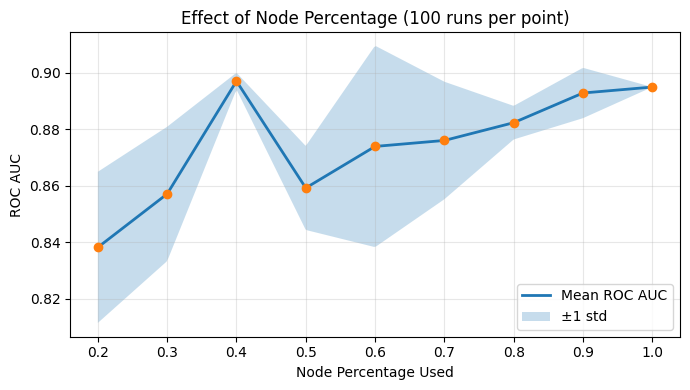

In [27]:
class Config:
    def __init__(self):
        self.results_root = "/home/reza/Documents/Reza_projects/08_drarabi_lymphnodes/cleaned_code/Results"
        self.model_name = "mil"
        self.use_demographic = True
        self.use_coords = True

cfg = Config()
sweep_results = sweep_percentage_aggregator(cfg, metric='roc_auc')
plot_reults(sweep_results)

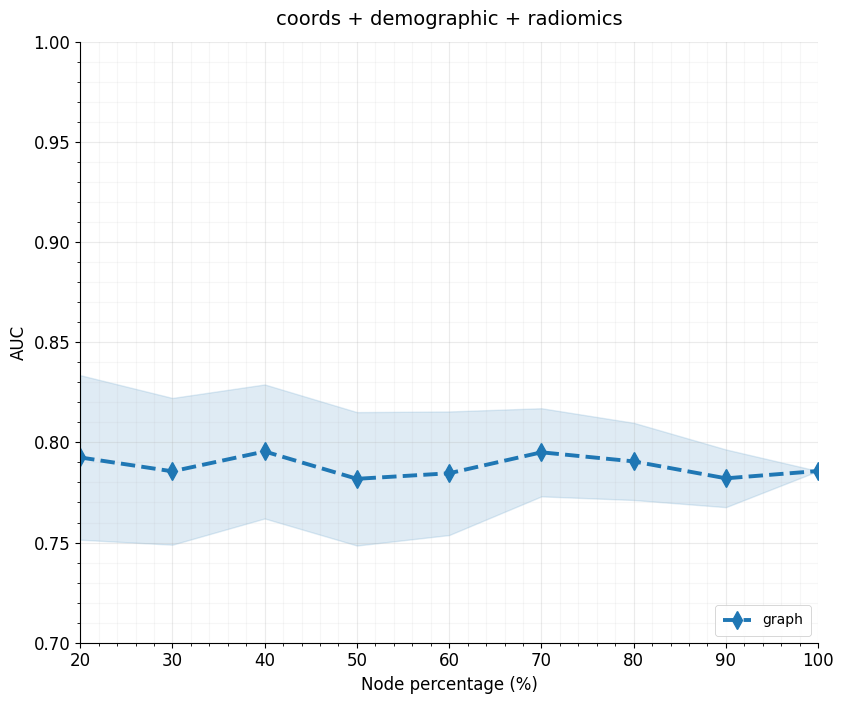

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def plot_percentage_auc_compare_fancy(
    model_to_sweep_results,
    title="Node-percentage vs AUC",
    show_points=False,
    show_band=True,
    show_grid=True,
    legend_loc="lower right",
    ylim=(0.0, 1.0),
    savepath=None,
    dpi=300,
    ax=None,
):
    """
    model_to_sweep_results: dict[str, dict[float, list[float]]]
        {
          "mil": {0.2:[...], 0.3:[...], ..., 1.0:[...]},
          "deepsets": {...},
          ...
        }
    """
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8.6, 7.2))
        created_fig = True
    else:
        fig = ax.figure

    ax.set_title(title, pad=12)

    if show_grid:
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.10)
        ax.minorticks_on()

    for model_name, sweep_results in model_to_sweep_results.items():
        # sort by percentage
        ps = sorted(sweep_results.keys())
        x = np.array(ps) * 100.0  # percentage in [20..100]

        means, stds = [], []
        for p in ps:
            vals = np.asarray(sweep_results[p], dtype=float)
            vals = vals[~np.isnan(vals)]
            if vals.size == 0:
                means.append(np.nan)
                stds.append(np.nan)
            else:
                means.append(float(np.mean(vals)))
                stds.append(float(np.std(vals)))

        y = np.array(means, dtype=float)
        ystd = np.array(stds, dtype=float)

        # main line
        (line,) = ax.plot(
            x, y, 
            lw=2.8,
            linestyle="--",
            marker="d", markersize=9,
            label=f"{model_name}" #| AUC={np.nanmean(y):.3f}±{np.nanstd(y):.3f}
        )

        # optional band (mean ± std)
        if show_band:
            color = line.get_color()
            lower = np.clip(y - ystd, 0.0, 1.0)
            upper = np.clip(y + ystd, 0.0, 1.0)
            ax.fill_between(x, lower, upper, alpha=0.14, color=color)

        # optional points per percentage
        if show_points:
            color = line.get_color()
            for p in ps:
                vals = np.asarray(sweep_results[p], dtype=float)
                vals = vals[~np.isnan(vals)]
                if vals.size:
                    ax.scatter(
                        np.full(vals.shape, p * 100.0),
                        vals,
                        s=10,
                        alpha=0.15,
                        color=color,
                        edgecolors="none",
                    )

    ax.set_xlabel("Node percentage (%)")
    ax.set_ylabel("AUC")
    ax.set_xlim(20, 100)
    ax.set_ylim(*ylim)

    leg = ax.legend(loc=legend_loc, frameon=True, framealpha=0.9, borderpad=0.6)
    leg.get_frame().set_linewidth(0.6)

    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

    if created_fig:
        fig.tight_layout()
        plt.show()

from copy import deepcopy

def build_model_to_sweep_results(cfg, model_list, metric="roc_auc"):
    """
    Returns:
      dict[model_name -> sweep_results]
    """
    model_to_sweep = {}
    for model_name in model_list:
        cfg_local = deepcopy(cfg)
        cfg_local.model_name = model_name
        model_to_sweep[model_name] = sweep_percentage_aggregator(cfg_local, metric=metric)
    return model_to_sweep


cfg = Config()
cfg.use_coords = True
cfg.use_demographic = True

model_list = ["graph"]  # <-- your models
model_to_sweep = build_model_to_sweep_results(cfg, model_list, metric="roc_auc")

plot_percentage_auc_compare_fancy(
    model_to_sweep,
    title="coords + demographic + radiomics",
    show_points=False,
    show_band=True,
    legend_loc="lower right",
    savepath="figures/percentage_auc_coords_demo_radiomics.png",
    ylim=(0.7, 1.0)
)



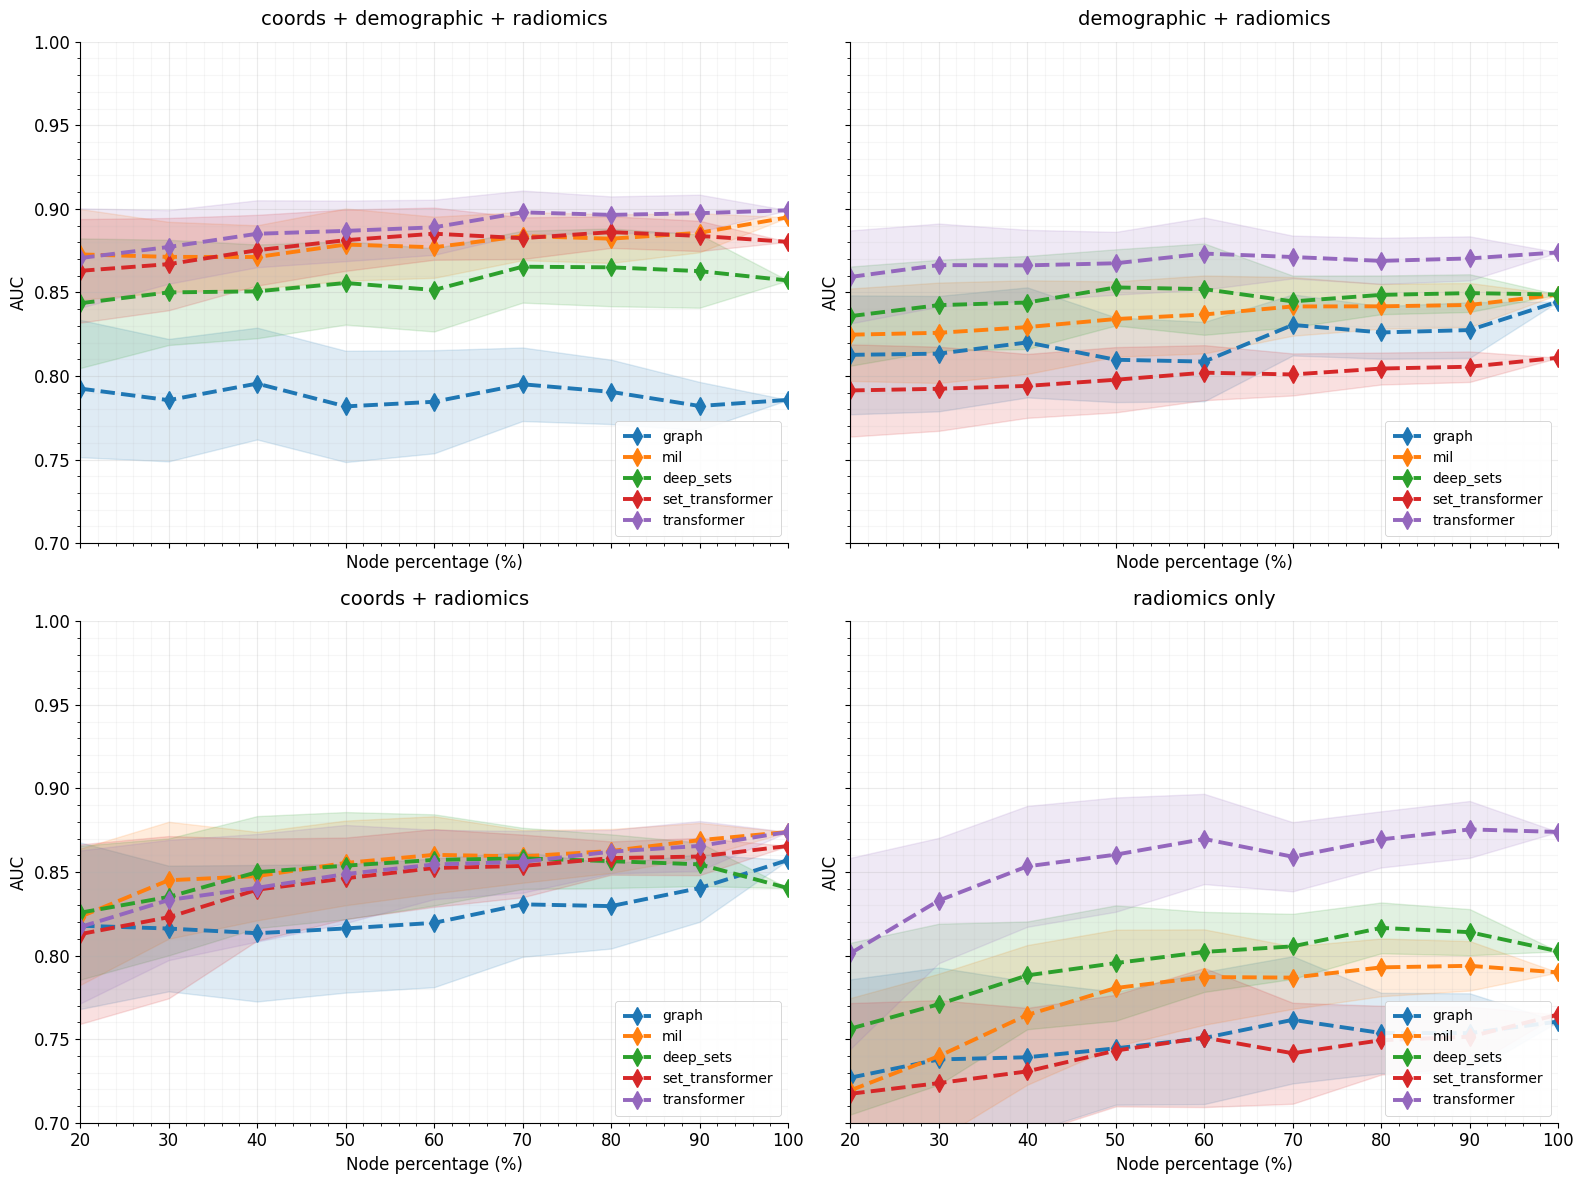

In [66]:
def comparison_plot_percentage_auc_curves(
    cfg,
    model_list,
    metric="roc_auc",
    savepath="figures/percentage_auc_comparison.png",
    dpi=300,
):
    fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)

    configs = [
        (True,  True,  "coords + demographic + radiomics"),
        (False, True,  "demographic + radiomics"),
        (True,  False, "coords + radiomics"),
        (False, False, "radiomics only"),
    ]

    for ax, (use_coords, use_demo, subtitle) in zip(axs.ravel(), configs):
        cfg.use_coords = use_coords
        cfg.use_demographic = use_demo

        model_to_sweep = build_model_to_sweep_results(cfg, model_list, metric=metric)

        plot_percentage_auc_compare_fancy(
            model_to_sweep,
            title=subtitle,
            ax=ax,
            show_points=False,
            show_band=True,
            legend_loc="lower right",
            ylim=(0.7, 1.0),
        )

    fig.tight_layout()
    fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
    plt.show()

cfg = Config()
model_list = ["graph", "mil", "deep_sets", "set_transformer", "transformer"]

comparison_plot_percentage_auc_curves(
    cfg,
    model_list,
    metric="roc_auc",
    savepath="figures/percentage_auc_comparison_center1.png",
    dpi=300,
)
